# DATA PREPARATION

In [1]:
# INITIATION: PYTHON AND DISPLAY

# Import libraries
import pandas as pd #
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt #charts
import seaborn as sns #charts

# For better visibility
from IPython.display import display, HTML

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))

In [2]:
# FILE LOAD

# Read the Excel file into a DataFrame
df_filter = pd.read_excel('2000 Analysis Python CHANGED.xlsx', decimal=',')

# GRAPHICAL ANALYSIS

In [3]:
#FUNCTION TO ANALYSE COMBINATIONS AND OUTPUT A TABLE

def analyze_combinations(data, year, columns_to_analyze, split_by_column, result_filename=None):
    # Step 1: Filter the data for the specified year
    data_filtered = data[data['Year'] == year].copy()

    # Step 2: Calculate detailed combination of the specified columns
    def create_combination(row, columns):
        return ' & '.join([f"{col} Yes" if row[col] == 'Yes' else f"{col} No" for col in columns])

    data_filtered['Combination'] = data_filtered.apply(lambda row: create_combination(row, columns_to_analyze), axis=1)

    # Step 3: Create a pivot table to split results by the specified column
    pivot_table = pd.pivot_table(
        data_filtered,
        values='Name',  # 'Name' is used to count occurrences
        index='Combination',
        columns=split_by_column,
        aggfunc='count',
        fill_value=0,
        observed=False  # Explicitly set observed=False to avoid the warning
    )

    # Step 4: Add a Total column to the pivot table
    pivot_table['Total'] = pivot_table.sum(axis=1)

    # Step 5: Add a Total row for all combinations
    pivot_table.loc['Total'] = pivot_table.sum(axis=0)

    # Step 6: Calculate the proportions
    proportions_table = pivot_table.div(pivot_table.loc['Total'], axis=1).map(lambda x: f"{x:.2%}")

    # Display the tables side by side using HTML
    html_table = f"""
    <div style="display: flex; justify-content: flex-start; gap: 1cm;">
        <div>
            <h3>Counts of {', '.join(columns_to_analyze)} Combinations for {year}</h3>
            {pivot_table.to_html()}
        </div>
        <div>
            <h3>Proportions of {', '.join(columns_to_analyze)} Combinations for {year}</h3>
            {proportions_table.to_html()}
        </div>
    </div>
    """
    display(HTML(html_table))

    # Save the pivot and proportions tables to an Excel file if a filename is provided
    if result_filename:
        with pd.ExcelWriter(result_filename) as writer:
            pivot_table.to_excel(writer, sheet_name='Counts')
            proportions_table.to_excel(writer, sheet_name='Proportions')
        print(f"Results saved to {result_filename}")

In [4]:
#FUNCTION TO ANALYSE COMBINATIONS AND OUTPUT A CHART

def create_chart(data, year, columns_to_analyze, split_by_column=None, filter_value=None, title=None):
    # Step 1: Filter the data for the specified year
    data_filtered = data[data['Year'] == year].copy()

    # Step 2: Calculate detailed combination of the specified columns
    def create_combination(row, columns):
        return ' & '.join([f"{col} Yes" if row[col] == 'Yes' else f"{col} No" for col in columns])

    data_filtered['Combination'] = data_filtered.apply(lambda row: create_combination(row, columns_to_analyze), axis=1)

    # Step 3: Apply additional filtering if needed (e.g., split by a column value like 'P' or 'F')
    if split_by_column and filter_value:
        data_filtered = data_filtered[data_filtered[split_by_column] == filter_value]

    # Step 4: Calculate total counts for each combination
    combination_counts = data_filtered['Combination'].value_counts()

    # Step 5: Determine positions based on the number of columns
    if len(columns_to_analyze) == 2:
        positions = {
            f"{columns_to_analyze[0]} Yes & {columns_to_analyze[1]} Yes": (0.75, 0.75),
            f"{columns_to_analyze[0]} No & {columns_to_analyze[1]} Yes": (0.25, 0.75),
            f"{columns_to_analyze[0]} Yes & {columns_to_analyze[1]} No": (0.75, 0.25),
            f"{columns_to_analyze[0]} No & {columns_to_analyze[1]} No": (0.25, 0.25)
        }
    else:
        raise ValueError("This chart only supports 2 columns for analysis.")

    x_labels = ['No', 'Yes']
    y_labels = ['No', 'Yes']

    # Step 6: Plot the data
    fig, ax = plt.subplots(figsize=(8, 8))

    for combination, (x, y) in positions.items():
        count = combination_counts.get(combination, 0)
        ax.scatter(x, y, s=count*70, alpha=0.6, color='#4CAF50', edgecolor='black')
        ax.text(x, y, f'{count}', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(x_labels)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(y_labels)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(columns_to_analyze[0], fontsize=14)
    ax.set_ylabel(columns_to_analyze[1], fontsize=14)
    ax.axhline(0.5, color='black', linewidth=1)
    ax.axvline(0.5, color='black', linewidth=1)
    
    if title:
        plt.title(title, fontsize=16)
    
    plt.tight_layout()
    plt.show()

In [8]:
# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2023, 
    columns_to_analyze=['Drop_Sales_2020', 'Hint'], 
    split_by_column='3_Growth_Categories',
    result_filename='hg_hint_combinations_2023.xlsx'
)

# TABLE FUNCTION EXECUTION:
analyze_combinations(
    data=df_filter, 
    year=2023, 
    columns_to_analyze=['P/F', 'Drop_Sales_2020'], 
    split_by_column='3_Growth_Categories',
)

3_Growth_Categories,GN0,GN1,GN2,Total
Combination,,,,
Drop_Sales_2020 No & Hint No,83,105,171,359
Drop_Sales_2020 No & Hint Yes,65,75,111,251
Drop_Sales_2020 Yes & Hint No,287,145,92,524
Drop_Sales_2020 Yes & Hint Yes,221,90,58,369
Total,656,415,432,1503
3_Growth_Categories,GN0,GN1,GN2,Total
Combination,,,,
Drop_Sales_2020 No & Hint No,12.65%,25.30%,39.58%,23.89%
Drop_Sales_2020 No & Hint Yes,9.91%,18.07%,25.69%,16.70%


Results saved to hg_hint_combinations_2023.xlsx


3_Growth_Categories,GN0,GN1,GN2,Total
Combination,,,,
P/F No & Drop_Sales_2020 No,148,180,282,610
P/F No & Drop_Sales_2020 Yes,508,235,150,893
Total,656,415,432,1503
3_Growth_Categories,GN0,GN1,GN2,Total
Combination,,,,
P/F No & Drop_Sales_2020 No,22.56%,43.37%,65.28%,40.59%
P/F No & Drop_Sales_2020 Yes,77.44%,56.63%,34.72%,59.41%
Total,100.00%,100.00%,100.00%,100.00%


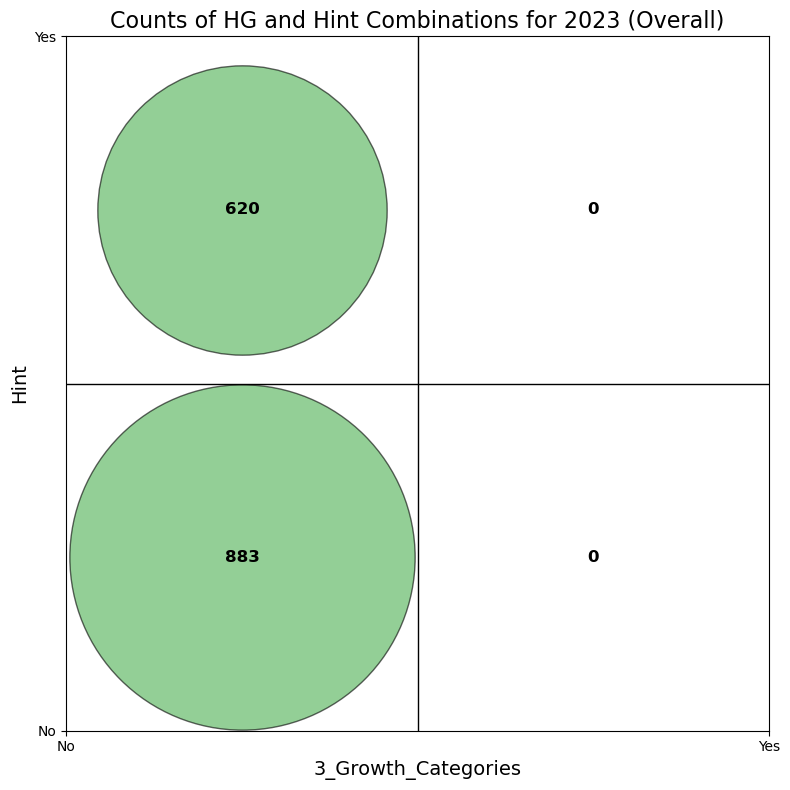

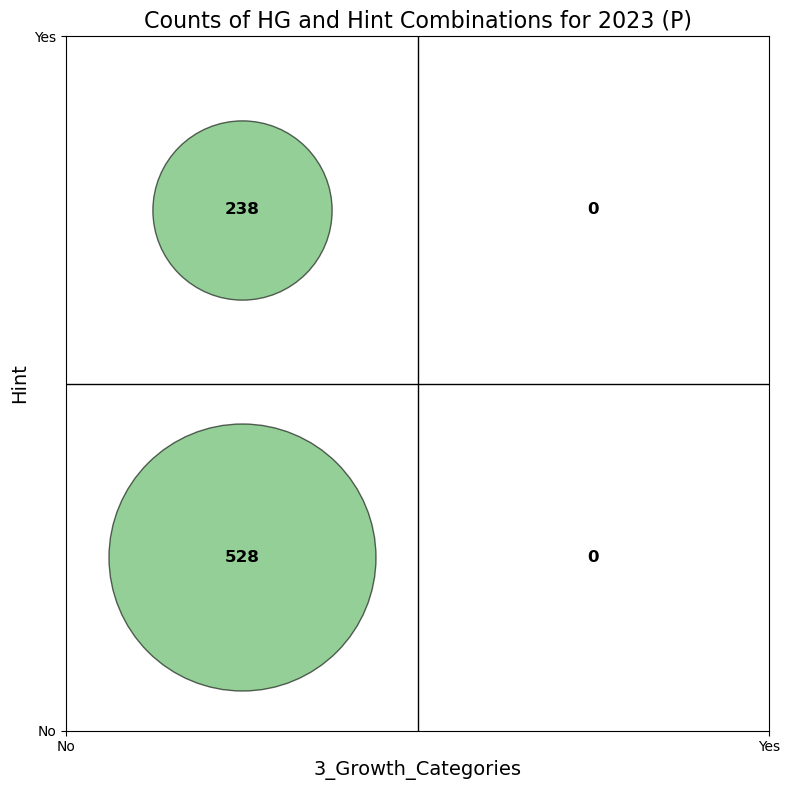

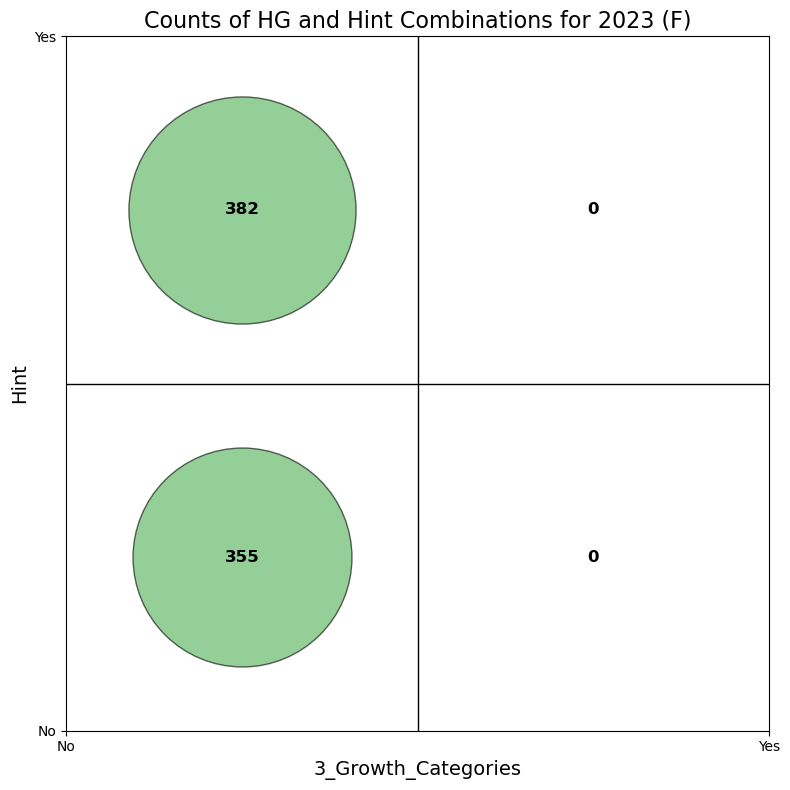

In [10]:
# CHART FUNCTION EXECUTION

# Generate a chart for overall data
create_chart(
    data=df_filter, 
    year=2023, 
    columns_to_analyze=['3_Growth_Categories', 'Hint'], 
    title='Counts of HG and Hint Combinations for 2023 (Overall)'
)

# Generate a chart for the 'P' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2023, 
    columns_to_analyze=['3_Growth_Categories', 'Hint'], 
    split_by_column='P/F', 
    filter_value='P', 
    title='Counts of HG and Hint Combinations for 2023 (P)'
)

# Generate a chart for the 'F' category in the 'P/F' column
create_chart(
    data=df_filter, 
    year=2023, 
    columns_to_analyze=['3_Growth_Categories', 'Hint'], 
    split_by_column='P/F', 
    filter_value='F', 
    title='Counts of HG and Hint Combinations for 2023 (F)'
)

In [15]:
# Filter the data to find companies that experienced both Drop_Sales and have HG

name_filter = df_filter[(df_filter['Drop_Sales_2020'] == 'Yes') & (df_filter['3_Growth_Categories'] == 'GN2')][['Name', 'Sales','P/F']]

display(name_filter)

,Name,Sales,P/F
7,"ArcelorMittal Poland SA GK, Dąbrowa Górnicza","33 491 349,00",F
10,"Polskie Sieci Elektroenergetyczne SA, Konstancin","26 406 192,20",P
18,"Jastrzębska Spółka Węglowa SA, Jastrzębie–Zdrój","19 757 700,00",P
19,"AB SA GK, Magnice","19 225 619,00",P
22,"LPP SA GK, Gdańsk","17 406 200,00",P
28,"Grupa Kapitałowa Maspex SA , Wadowice","14 988 147,50",P
30,"Man Trucks sp. z o.o., Niepołomice","14 803 907,00",F
44,"Cedrob SA GK, Ciechanów","11 807 533,00",P
72,"Respect Energy Holding, Warszawa","7 529 702,00",P
86,"PKP Energetyka Kolejowa SA, Warszawa","6 398 465,00",P


In [16]:
# Filter the data for the year 2023
df_2023 = df_filter[df_filter['Year'] == 2023]

# Step 1: Calculate average sales by growth category for the year 2023
unique_growth_sales_2023 = df_2023.groupby('Growth_Category')['Sales'].mean()

# Step 2: Calculate profitability metrics (ROA, ROS, ROE) by growth category for 2023 using actual calculation
# ROA = Net Profit / Total Assets
# ROS = Net Profit / Sales
# ROE = Net Profit / Equity

growth_assets_2023 = df_2023.groupby('Growth_Category')['BS'].sum()
growth_sales_2023 = df_2023.groupby('Growth_Category')['Sales'].sum()
growth_net_profit_2023 = df_2023.groupby('Growth_Category')['Net Profit'].sum()
growth_equity_2023 = df_2023.groupby('Growth_Category')['Equity'].sum()

unique_growth_roa_2023 = (growth_net_profit_2023 / growth_assets_2023) * 100
unique_growth_ros_2023 = (growth_net_profit_2023 / growth_sales_2023) * 100
unique_growth_roe_2023 = (growth_net_profit_2023 / growth_equity_2023) * 100

# Display the results as a table
profitability_df = pd.DataFrame({
    'Average Sales (in billions)': unique_growth_sales_2023,
    'ROA (%)': unique_growth_roa_2023,
    'ROS (%)': unique_growth_ros_2023,
    'ROE (%)': unique_growth_roe_2023
})

from IPython.display import display

display(profitability_df)

# Step 3: Plot the charts for 2023 data

# Plot: Average Sales by Growth Category (2023 only)
plt.figure(figsize=(6, 4))
plt.bar(unique_growth_sales_2023.index, unique_growth_sales_2023, color='skyblue')
plt.title('Average Sales by Growth Category (2023 Only)')
plt.ylabel('Average Sales (in billions)')
plt.xlabel('Growth Category')
plt.show()

# Plot: Profitability Metrics (ROA, ROS, ROE) by Growth Category (2023 only)
plt.figure(figsize=(6, 4))
plt.plot(unique_growth_roa_2023.index, unique_growth_roa_2023, label='ROA', marker='o')
plt.plot(unique_growth_ros_2023.index, unique_growth_ros_2023, label='ROS', marker='o')
plt.plot(unique_growth_roe_2023.index, unique_growth_roe_2023, label='ROE', marker='o')
plt.title('Profitability Metrics by Growth Category (2023 Only)')
plt.ylabel('Profitability Ratios (%)')
plt.xlabel('Growth Category')
plt.legend()
plt.show()


KeyError: 'Growth_Category'

In [17]:
# Total count by Growth Category
total_count = df_2023['Growth_Category'].value_counts(normalize=True)

# Total sales by Growth Category
total_sales = df_2023.groupby('Growth_Category')['Sales'].sum()
sales_proportion = total_sales / total_sales.sum()

# Total net profit by Growth Category (use existing Net Profit column)
total_net_profit = df_2023.groupby('Growth_Category')['Net Profit'].sum()
net_profit_proportion = total_net_profit / total_net_profit.sum()

# Create a DataFrame to display the proportions
proportions_df = pd.DataFrame({
    'Count Proportion': total_count,
    'Sales Proportion': sales_proportion,
    'Net Profit Proportion': net_profit_proportion
})

# Data preparation
categories = proportions_df.index
count_prop = proportions_df['Count Proportion']
sales_prop = proportions_df['Sales Proportion']
net_profit_prop = proportions_df['Net Profit Proportion']

x = np.arange(len(categories))  # label locations
width = 0.25  # width of the bars

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for Count, Sales, and Net Profit proportions
bars1 = ax.bar(x - width, count_prop, width, label='Ilość firm', color='skyblue')
bars2 = ax.bar(x, sales_prop, width, label='Udział sprzedaży', color='lightgreen')
bars3 = ax.bar(x + width, net_profit_prop, width, label='Udział zysku', color='salmon')

# Adding labels, title, and customizations
ax.set_xlabel('Kategoria Wzrostu')
ax.set_ylabel('Proporcja')
ax.set_title('Proporcja ilości firm, sprzedaży i zysku netto')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Adding percentage labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2%}',  # Display values as percentages
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()

# Save the chart as an image
plt.savefig('count sales and net profit.png')

plt.show()

KeyError: 'Growth_Category'

In [18]:
# Extract relevant columns: Growth_Category and P/F for the year 2023
aggregation_df = df_2023[['Growth_Category', 'P/F']].copy()

# Count the number of occurrences per Growth_Category and P/F for 2023 using the P/F column directly
aggregated_data = aggregation_df.groupby(['Growth_Category', 'P/F']).size().reset_index(name='Count')

# Pivot the table for easier plotting
pivot_table = aggregated_data.pivot(index='Growth_Category', columns='P/F', values='Count').fillna(0)

# Extract the required data for plotting
categories = pivot_table.index
zagraniczne = pivot_table['F'] if 'F' in pivot_table else [0] * len(categories)
polskie = pivot_table['P'] if 'P' in pivot_table else [0] * len(categories)

# Calculate the total count for the entire population for percentage calculations
total_count = zagraniczne.sum() + polskie.sum()
percent_zagraniczne_total = (zagraniczne / total_count) * 100
percent_polskie_total = (polskie / total_count) * 100

# Create the stacked bar chart
plt.figure(figsize=(10, 6))
bars1 = plt.bar(categories, zagraniczne, label='Zagraniczne', color='skyblue')
bars2 = plt.bar(categories, polskie, bottom=zagraniczne, label='Polskie', color='orange')

# Add percentage labels within the bars as % of total population
for bar, value, percentage in zip(bars1, zagraniczne, percent_zagraniczne_total):
    plt.text(bar.get_x() + bar.get_width() / 2, value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom, value, percentage in zip(bars2, zagraniczne, polskie, percent_polskie_total):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

plt.xlabel('Kategoria Wzrostu')
plt.ylabel('Liczba')
plt.title('Porównanie Liczby Zagranicznych i Polskich w Różnych Kategoriach (% z Całkowitej Populacji)')
plt.legend()

# Save the chart as an image
plt.savefig('stacked_bar_chart.png')

plt.show()


KeyError: "['Growth_Category'] not in index"

In [19]:
# Extract relevant columns: Growth_Category, P/F, and Hint for the year 2023
aggregation_df = df_2023[['Growth_Category', 'P/F', 'Hint']].copy()

# Count the number of occurrences per Growth_Category, P/F, and Hint for 2023
aggregated_data = aggregation_df.groupby(['Growth_Category', 'P/F', 'Hint']).size().reset_index(name='Count')

# Pivot the table for easier plotting
pivot_table = aggregated_data.pivot_table(index='Growth_Category', columns=['P/F', 'Hint'], values='Count', fill_value=0)

# Extract the required data for plotting
categories = pivot_table.index

# Prepare data for plotting
zagraniczne_yes = pivot_table[('F', 'Yes')] if ('F', 'Yes') in pivot_table else [0] * len(categories)
zagraniczne_no = pivot_table[('F', 'No')] if ('F', 'No') in pivot_table else [0] * len(categories)
polskie_yes = pivot_table[('P', 'Yes')] if ('P', 'Yes') in pivot_table else [0] * len(categories)
polskie_no = pivot_table[('P', 'No')] if ('P', 'No') in pivot_table else [0] * len(categories)

# Calculate the total count for the entire population for percentage calculations
total_count = zagraniczne_yes.sum() + zagraniczne_no.sum() + polskie_yes.sum() + polskie_no.sum()
percent_zagraniczne_yes = (zagraniczne_yes / total_count) * 100
percent_zagraniczne_no = (zagraniczne_no / total_count) * 100
percent_polskie_yes = (polskie_yes / total_count) * 100
percent_polskie_no = (polskie_no / total_count) * 100

# Create the stacked bar chart
plt.figure(figsize=(12, 8))
bars1 = plt.bar(categories, zagraniczne_yes, label='Zagraniczne (Tak)', color='skyblue')
bars2 = plt.bar(categories, zagraniczne_no, bottom=zagraniczne_yes, label='Zagraniczne (Nie)', color='lightblue')
bars3 = plt.bar(categories, polskie_yes, bottom=zagraniczne_yes + zagraniczne_no, label='Polskie (Tak)', color='orange')
bars4 = plt.bar(categories, polskie_no, bottom=zagraniczne_yes + zagraniczne_no + polskie_yes, label='Polskie (Nie)', color='wheat')

# Add percentage labels within the bars as % of total population
for bar, value, percentage in zip(bars1, zagraniczne_yes, percent_zagraniczne_yes):
    plt.text(bar.get_x() + bar.get_width() / 2, value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom, value, percentage in zip(bars2, zagraniczne_yes, zagraniczne_no, percent_zagraniczne_no):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom1, bottom2, value, percentage in zip(bars3, zagraniczne_yes, zagraniczne_no, polskie_yes, percent_polskie_yes):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom1 + bottom2 + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

for bar, bottom1, bottom2, bottom3, value, percentage in zip(bars4, zagraniczne_yes, zagraniczne_no, polskie_yes, polskie_no, percent_polskie_no):
    plt.text(bar.get_x() + bar.get_width() / 2, bottom1 + bottom2 + bottom3 + value / 2, f'{percentage:.1f}%', ha='center', va='center', color='black', fontsize=10)

plt.xlabel('Kategoria Wzrostu')
plt.ylabel('Liczba')
plt.title('Porównanie Liczby Zagranicznych i Polskich w Różnych Kategoriach z Podziałem na Hint (% z Całkowitej Populacji)')
plt.legend()

# Save the chart as an image
plt.savefig('stacked_bar_chart_with_hint.png')

plt.show()

KeyError: "['Growth_Category'] not in index"

In [20]:
# Step 1: Total count, sales, and net profit by growth category
# Total count by Growth Category
total_count = df_2023['Growth_Category'].value_counts()

# Total sales by Growth Category
total_sales = df_2023.groupby('Growth_Category')['Sales'].sum()
sales_proportion = total_sales / total_sales.sum()

# Total net profit by Growth Category (use existing Net Profit column)

# Calculate ROS (Return on Sales) by Growth Category
unique_growth_ros_2023 = (total_net_profit / total_sales) * 100
total_net_profit = df_2023.groupby('Growth_Category')['Net Profit'].sum()
net_profit_proportion = total_net_profit / total_net_profit.sum()

# Create a DataFrame to display the proportions
proportions_df = pd.DataFrame({
    'Count Proportion': total_count / total_count.sum(),
    'Sales Proportion': sales_proportion,
    'Net Profit Proportion': net_profit_proportion
})

# Data preparation
categories = proportions_df.index
count_prop = proportions_df['Count Proportion']
sales_prop = proportions_df['Sales Proportion']
net_profit_prop = proportions_df['Net Profit Proportion']

x = np.arange(len(categories))  # label locations
width = 0.25  # width of the bars

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for Count, Sales, and Net Profit proportions
bars1 = ax.bar(x - width, count_prop, width, label='Ilość firm', color='skyblue')
bars2 = ax.bar(x, sales_prop, width, label='Udział sprzedaży / średnia sprzedaż', color='lightgreen')
bars3 = ax.bar(x + width, net_profit_prop, width, label='Udział w zysku / ROS', color='salmon')

# Adding labels, title, and customizations
ax.set_xlabel('Kategoria Wzrostu')
ax.set_ylabel('Proporcja')
ax.set_title('Proporcja ilości firm, sprzedaży i zysku netto')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Adding numbers inside bars in a user-friendly format and adding % proportions above bars
def add_labels(bars, values, format_type):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if format_type == 'count':
            label = f'{int(value)}'
        elif format_type == 'sales':
            label = f'{value:,.0f} tys.'
        elif format_type == 'ros':
            label = f'{value:.2f}%'
        # Display the actual value in formatted form vertically inside the bar
        ax.annotate(label,
                    xy=(bar.get_x() + bar.get_width() / 2, height / 2),
                    xytext=(0, 0),
                    textcoords="offset points",
                    ha='center', va='bottom', rotation='vertical', color='black')
        # Display the percentage proportion above the bar
        ax.annotate(f'{height:.1%}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', color='black')

# Adding specific values for each bar type
add_labels(bars1, total_count, 'count')
add_labels(bars2, unique_growth_sales_2023 / 1000, 'sales')  # Display average sales in thousands
add_labels(bars3, unique_growth_ros_2023, 'ros')  # Display ROS in percentage

plt.tight_layout()

# Save the chart as an image
plt.savefig('count sales and net profit.png')

plt.show()


KeyError: 'Growth_Category'